# 05 — Experiment 4A: paced breathing

Experiment 4A is the report's cleanest controlled dose-response design:
five metronome-guided breathing rates performed in a fixed descending order
(`12 → 9 → 6 → 5 → 3 breaths/min`). The notebook upgrades the original
analysis to publication-quality figures, fuller regression reporting, and
manuscript-ready text while keeping `src/pipeline.py` unchanged.

**Core findings preview**
- The RR-spectral peak tracks the imposed breathing frequency almost perfectly (`R² = 0.998`).
- As breathing slows below `0.15 Hz`, spectral power migrates from HF into LF and inflates LF/HF.
- RR amplitude increases monotonically across the tested range rather than showing a classical inverted-U resonance peak.
- The fixed descending order is a real limitation and is acknowledged explicitly in the Discussion.

In [1]:
from __future__ import annotations

import math
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress, t as t_dist

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import config as cfg
from src import pipeline as P
from src import plotting as PL

def apply_ieee_tbme_style():
    PL.apply_style()
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 9,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "figure.titlesize": 10,
        "lines.linewidth": 1.1,
        "axes.linewidth": 0.6,
        "savefig.bbox": "tight",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

def _panel_label(ax, text, pad=6):
    ax.set_title(text, loc="left", fontweight="bold", fontsize=9, pad=pad)

def save_paper_png(fig, filename):
    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")

apply_ieee_tbme_style()
warnings.filterwarnings("ignore", category=RuntimeWarning)

FIG_DIR = REPO_ROOT / "outputs" / "paper_figures_png"
TBL_DIR = REPO_ROOT / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)

NPERSEG_PUB = 512
FREQ_RES_HZ = cfg.INTERP_FREQ / NPERSEG_PUB
E4A_KEYS = ["E4A_12pm", "E4A_9pm", "E4A_6pm", "E4A_5pm", "E4A_3pm"]
E4A_PSD_COLORS = {
    "E4A_12pm": "#3b4cc0",
    "E4A_9pm": "#7b9ef7",
    "E4A_6pm": "#59a14f",
    "E4A_5pm": "#f28e2b",
    "E4A_3pm": "#e15759",
}
E4A_TACH_LABELS = {
    "E4A_12pm": "(a) 12 breaths/min",
    "E4A_9pm": "(b) 9 breaths/min",
    "E4A_6pm": "(c) 6 breaths/min",
    "E4A_5pm": "(d) 5 breaths/min",
    "E4A_3pm": "(e) 3 breaths/min",
}

print(f"Setup complete. Publication Welch nperseg={NPERSEG_PUB} ({FREQ_RES_HZ:.4f} Hz resolution).")

Setup complete. Publication Welch nperseg=512 (0.0078 Hz resolution).


## 1. Run steady-state pipeline across the five paced-breathing conditions

In [2]:
results = {k: P.analyze_steady_state(k) for k in E4A_KEYS}
for k, r in results.items():
    exp_hz = cfg.E4A_EXPECTED_BREATHING_HZ[k]
    print(
        f"{k}: HR={r.td_hrv['mean_hr_bpm']:.1f} bpm | "
        f"SDNN={r.td_hrv['sdnn_ms']:.1f} ms | "
        f"RMSSD={r.td_hrv['rmssd_ms']:.1f} ms | "
        f"LF/HF={r.fd_hrv['lf_hf_ratio']:.2f} | "
        f"expected={exp_hz:.3f} Hz"
    )

E4A_12pm: HR=59.4 bpm | SDNN=48.7 ms | RMSSD=47.7 ms | LF/HF=0.22 | expected=0.200 Hz
E4A_9pm: HR=57.0 bpm | SDNN=78.0 ms | RMSSD=64.9 ms | LF/HF=0.84 | expected=0.150 Hz
E4A_6pm: HR=60.1 bpm | SDNN=91.3 ms | RMSSD=60.4 ms | LF/HF=11.54 | expected=0.100 Hz
E4A_5pm: HR=59.9 bpm | SDNN=95.9 ms | RMSSD=53.9 ms | LF/HF=17.45 | expected=0.083 Hz
E4A_3pm: HR=58.1 bpm | SDNN=131.4 ms | RMSSD=55.3 ms | LF/HF=17.47 | expected=0.050 Hz


## 1A. Pre-compute publication PSDs, RR peaks, EDR, and RSA summaries

In [3]:
psd_pub = {}
peak_pub = {}
for key in E4A_KEYS:
    r = results[key]
    f, p = P.rr_psd(r.rr_ms_nk, r.rr_times_nk, nperseg=NPERSEG_PUB)
    psd_pub[key] = (f, p)
    m = (f >= 0.01) & (f <= 0.45)
    peak_pub[key] = float(f[m][np.argmax(p[m])]) if m.any() else float("nan")

edr_pub = {k: P.derive_respiration_from_ecg(results[k].ecg_filt) for k in E4A_KEYS}
rsa_pub = {k: P.hrv_rsa_full(results[k].ecg_filt, fs=cfg.FS) for k in E4A_KEYS}

precompute_df = pd.DataFrame(
    {
        "Condition": E4A_KEYS,
        "Expected rate (Hz)": [cfg.E4A_EXPECTED_BREATHING_HZ[k] for k in E4A_KEYS],
        "Measured RR peak (Hz)": [peak_pub[k] for k in E4A_KEYS],
        "Peak deviation (Hz)": [abs(peak_pub[k] - cfg.E4A_EXPECTED_BREATHING_HZ[k]) for k in E4A_KEYS],
        "EDR rate (/min)": [edr_pub[k]["rate_bpm"] for k in E4A_KEYS],
        "RSA_P2T_Mean (ms)": [rsa_pub[k].get("RSA_P2T_Mean", np.nan) for k in E4A_KEYS],
    }
)
display(precompute_df.round(4))

,Condition,Expected rate (Hz),Measured RR peak (Hz),Peak deviation (Hz),EDR rate (/min),RSA_P2T_Mean (ms)
0,E4A_12pm,0.2000,0.2031,0.0031,12.0998,90.0952
1,E4A_9pm,0.1500,0.1484,0.0016,9.0040,156.5806
2,E4A_6pm,0.1000,0.1016,0.0016,6.6377,193.0000
3,E4A_5pm,0.0833,0.0859,0.0026,9.1511,138.0000
4,E4A_3pm,0.0500,0.0469,0.0031,8.3748,114.2778


## 2. Figure 4.1 — RR tachograms with RMSSD and respiratory inset

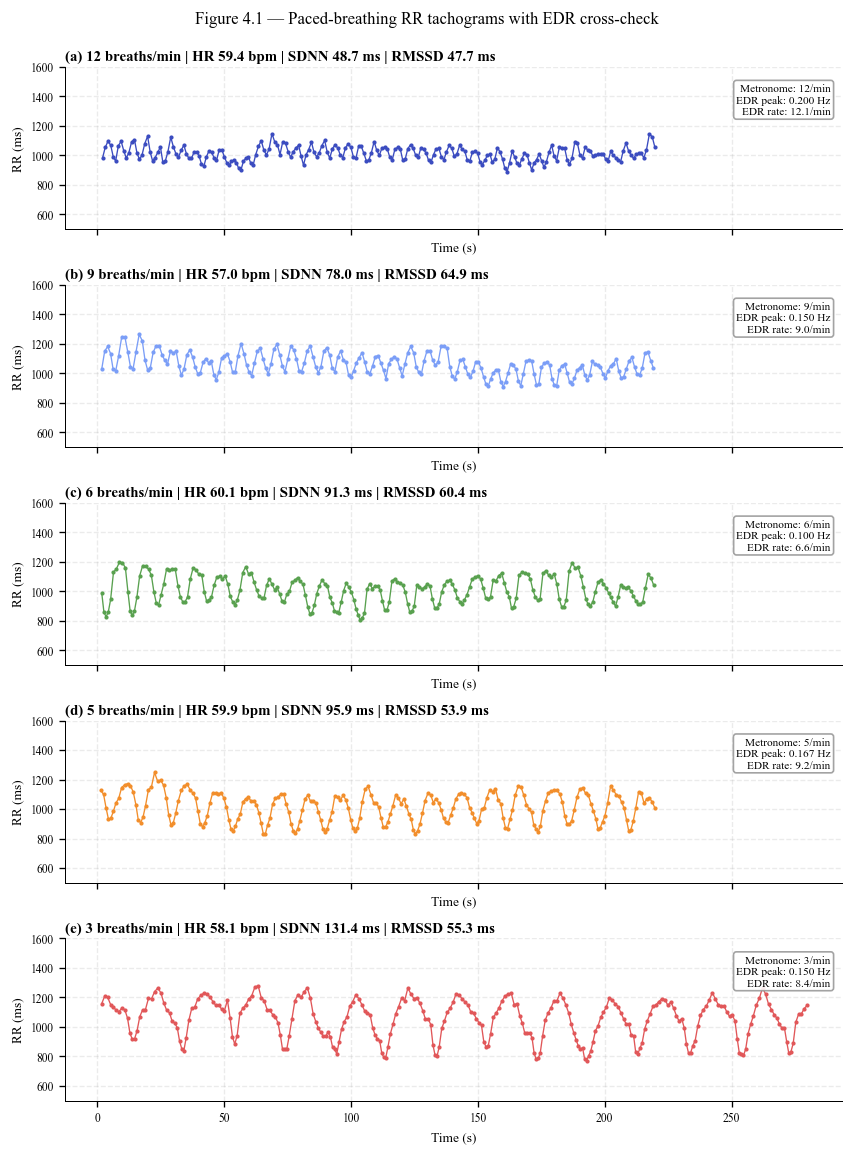

In [4]:
fig, axes = plt.subplots(5, 1, figsize=(7.16, 9.6), sharex=True)
for ax, key in zip(axes, E4A_KEYS):
    r = results[key]
    td = r.td_hrv
    edr = edr_pub[key]
    PL.plot_rr_tachogram(
        r.rr_ms_nk,
        r.rr_times_nk,
        ax=ax,
        color=E4A_PSD_COLORS[key],
        linewidth=0.8,
    )
    title = (
        f"{E4A_TACH_LABELS[key]} | HR {td['mean_hr_bpm']:.1f} bpm | "
        f"SDNN {td['sdnn_ms']:.1f} ms | RMSSD {td['rmssd_ms']:.1f} ms"
    )
    _panel_label(ax, title, pad=4)
    ax.set_ylim(500, 1600)
    ax.set_ylabel("RR (ms)")
    inset = (
        f"Metronome: {cfg.E4A_EXPECTED_BREATHING_HZ[key] * 60:.0f}/min\n"
        f"EDR peak: {edr['welch_peak_hz']:.3f} Hz\n"
        f"EDR rate: {edr['rate_bpm']:.1f}/min"
    )
    ax.text(
        0.985,
        0.90,
        inset,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=6.8,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.90, edgecolor="0.6"),
    )
    ax.grid(True, linestyle="--", alpha=0.25)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Figure 4.1 — Paced-breathing RR tachograms with EDR cross-check", y=0.995)
fig.tight_layout()
save_paper_png(fig, "MAIN_14_nb05_exp4a_tachograms.png")
plt.show()

## 3. Figure 4.2 — Money figure: single-panel PSD overlay with inset verification

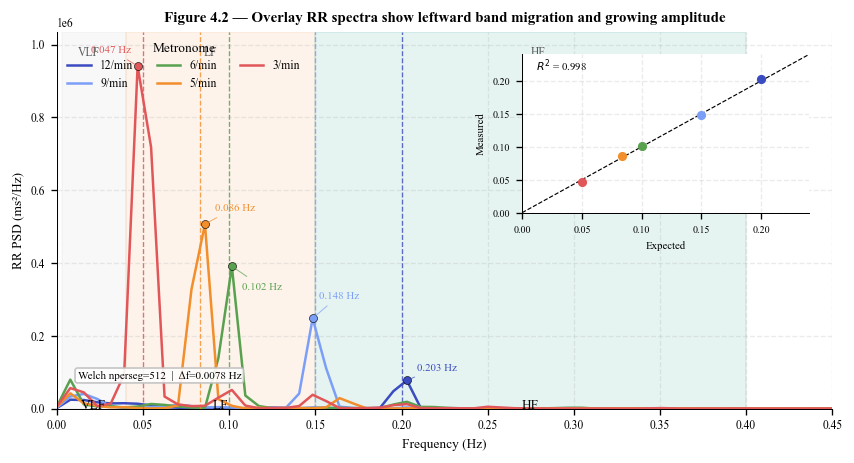

In [5]:
fig, ax = plt.subplots(figsize=(7.16, 3.9))

for band, (lo, hi) in cfg.BANDS.items():
    ax.axvspan(lo, hi, color=PL.BAND_COLORS.get(band, "#cccccc"), alpha=0.12, zorder=0)
    ax.text((lo + hi) / 2, ax.get_ylim()[1] if ax.lines else 1, band, ha="center")

peak_offsets = {
    "E4A_12pm": (6, 6),
    "E4A_9pm": (4, 12),
    "E4A_6pm": (6, -14),
    "E4A_5pm": (6, 8),
    "E4A_3pm": (-28, 8),
}

for key in E4A_KEYS:
    f, p = psd_pub[key]
    color = E4A_PSD_COLORS[key]
    label = f"{cfg.E4A_EXPECTED_BREATHING_HZ[key] * 60:.0f}/min"
    ax.plot(f, p, color=color, linewidth=1.5, label=label)

    target = cfg.E4A_EXPECTED_BREATHING_HZ[key]
    ax.axvline(target, color=color, linestyle="--", linewidth=0.8, alpha=0.8)

    peak_hz = peak_pub[key]
    m_peak = np.isclose(f, peak_hz)
    peak_power = float(p[m_peak][0]) if m_peak.any() else float("nan")
    ax.plot(peak_hz, peak_power, "o", color=color, markersize=4.8, markeredgecolor="black", markeredgewidth=0.35)
    dx, dy = peak_offsets[key]
    ax.annotate(
        f"{peak_hz:.3f} Hz",
        xy=(peak_hz, peak_power),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=6.6,
        color=color,
        arrowprops=dict(arrowstyle="-", color=color, lw=0.6, alpha=0.7),
    )

ymax = max(np.max(p) for _, p in psd_pub.values()) * 1.10
ax.set_xlim(0.0, 0.45)
ax.set_ylim(0.0, ymax)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("RR PSD (ms²/Hz)")
ax.set_title("Figure 4.2 — Overlay RR spectra show leftward band migration and growing amplitude")
ax.legend(title="Metronome", ncols=3, loc="upper left", frameon=False)
ax.text(
    0.012,
    ymax * 0.96,
    "VLF",
    fontsize=7,
    color="0.35",
    va="top",
)
ax.text(0.085, ymax * 0.96, "LF", fontsize=7, color="0.35", va="top")
ax.text(0.275, ymax * 0.96, "HF", fontsize=7, color="0.35", va="top")
ax.text(
    0.012,
    ymax * 0.08,
    f"Welch nperseg={NPERSEG_PUB}  |  Δf={FREQ_RES_HZ:.4f} Hz",
    fontsize=6.7,
    bbox=dict(boxstyle="round,pad=0.22", facecolor="white", edgecolor="0.75", alpha=0.9),
)

inset = ax.inset_axes([0.60, 0.52, 0.37, 0.42])
expected = np.array([cfg.E4A_EXPECTED_BREATHING_HZ[k] for k in E4A_KEYS])
measured = np.array([peak_pub[k] for k in E4A_KEYS])
xline = np.array([0.0, 0.24])
inset.plot(xline, xline, "k--", linewidth=0.7)
for key in E4A_KEYS:
    inset.plot(
        cfg.E4A_EXPECTED_BREATHING_HZ[key],
        peak_pub[key],
        "o",
        color=E4A_PSD_COLORS[key],
        markersize=4.5,
    )
inset.set_xlim(0.0, 0.24)
inset.set_ylim(0.0, 0.24)
inset.set_xlabel("Expected", fontsize=6.5)
inset.set_ylabel("Measured", fontsize=6.5)
inset.tick_params(labelsize=6)
inset.text(0.012, 0.215, f"$R^2$ = {np.corrcoef(expected, measured)[0, 1] ** 2:.3f}", fontsize=6.5)

fig.tight_layout()
save_paper_png(fig, "MAIN_15_nb05_exp4a_psd_overlay.png")
plt.show()

## 4. Figure 4.3 — Regression-grade peak-frequency verification

/var/folders/qz/c3j7zlrd2qqck8k99q5gp_tw0000gn/T/ipykernel_19890/3183807048.py:57: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Times New Roman.
  fig.tight_layout()
/var/folders/qz/c3j7zlrd2qqck8k99q5gp_tw0000gn/T/ipykernel_19890/671252416.py:44: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Times New Roman.
  fig.savefig(FIG_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")
/var/folders/qz/c3j7zlrd2qqck8k99q5gp_tw0000gn/T/ipykernel_19890/671252416.py:45: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Times New Roman.
  fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")
/Users/wupeien/Developer/hw5_ecg-analysis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)


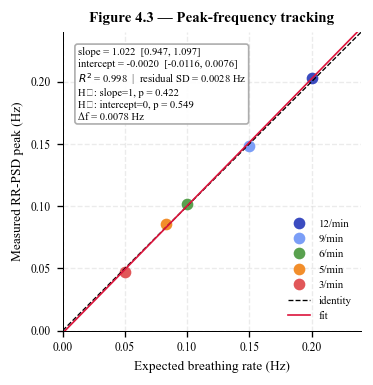

,slope,slope_ci_lo,slope_ci_hi,intercept,intercept_ci_lo,intercept_ci_hi,r_squared,residual_sd_hz,p_slope_eq_1,p_intercept_eq_0
0,1.02187,0.94679,1.09696,-0.00203,-0.01164,0.00758,0.9984,0.00278,0.42223,0.54942


In [6]:
x = np.array([cfg.E4A_EXPECTED_BREATHING_HZ[k] for k in E4A_KEYS], dtype=float)
y = np.array([peak_pub[k] for k in E4A_KEYS], dtype=float)
reg = linregress(x, y)
df = len(x) - 2
t_crit = t_dist.ppf(0.975, df)
slope_ci = (reg.slope - t_crit * reg.stderr, reg.slope + t_crit * reg.stderr)
intercept_ci = (
    reg.intercept - t_crit * reg.intercept_stderr,
    reg.intercept + t_crit * reg.intercept_stderr,
)
t_slope_eq_1 = (reg.slope - 1.0) / reg.stderr
p_slope_eq_1 = 2 * (1 - t_dist.cdf(abs(t_slope_eq_1), df))
t_intercept_eq_0 = reg.intercept / reg.intercept_stderr
p_intercept_eq_0 = 2 * (1 - t_dist.cdf(abs(t_intercept_eq_0), df))
residuals = y - (reg.slope * x + reg.intercept)
residual_sd = math.sqrt(np.sum(residuals**2) / df)

fig, ax = plt.subplots(figsize=(3.5, 3.25))
for key in E4A_KEYS:
    ax.plot(
        cfg.E4A_EXPECTED_BREATHING_HZ[key],
        peak_pub[key],
        "o",
        color=E4A_PSD_COLORS[key],
        markersize=6,
        label=f"{cfg.E4A_EXPECTED_BREATHING_HZ[key] * 60:.0f}/min",
    )
xline = np.linspace(0.0, 0.24, 200)
ax.plot(xline, xline, "k--", linewidth=0.8, label="identity")
ax.plot(xline, reg.slope * xline + reg.intercept, color="crimson", linewidth=1.0, label="fit")
ax.set_xlim(0.0, 0.24)
ax.set_ylim(0.0, 0.24)
ax.set_aspect("equal")
ax.set_xlabel("Expected breathing rate (Hz)")
ax.set_ylabel("Measured RR-PSD peak (Hz)")
ax.set_title("Figure 4.3 — Peak-frequency tracking")

stats_txt = (
    f"slope = {reg.slope:.3f}  [{slope_ci[0]:.3f}, {slope_ci[1]:.3f}]\n"
    f"intercept = {reg.intercept:.4f}  [{intercept_ci[0]:.4f}, {intercept_ci[1]:.4f}]\n"
    f"$R^2$ = {reg.rvalue ** 2:.3f}  |  residual SD = {residual_sd:.4f} Hz\n"
    f"H₀: slope=1, p = {p_slope_eq_1:.3f}\n"
    f"H₀: intercept=0, p = {p_intercept_eq_0:.3f}\n"
    f"Δf = {FREQ_RES_HZ:.4f} Hz"
)
ax.text(
    0.012,
    0.228,
    stats_txt,
    fontsize=6.4,
    va="top",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.65", alpha=0.92),
)
ax.legend(loc="lower right", fontsize=6.5, frameon=False)
ax.grid(True, linestyle="--", alpha=0.25)

fig.tight_layout()
save_paper_png(fig, "MAIN_16_nb05_exp4a_peak_tracking_regression.png")
plt.show()

reg_summary = pd.DataFrame(
    [{
        "slope": reg.slope,
        "slope_ci_lo": slope_ci[0],
        "slope_ci_hi": slope_ci[1],
        "intercept": reg.intercept,
        "intercept_ci_lo": intercept_ci[0],
        "intercept_ci_hi": intercept_ci[1],
        "r_squared": reg.rvalue ** 2,
        "residual_sd_hz": residual_sd,
        "p_slope_eq_1": p_slope_eq_1,
        "p_intercept_eq_0": p_intercept_eq_0,
    }]
)
display(reg_summary.round(5))

## 5. Figure 4.4 — LF/HF inflation versus RMSSD stability

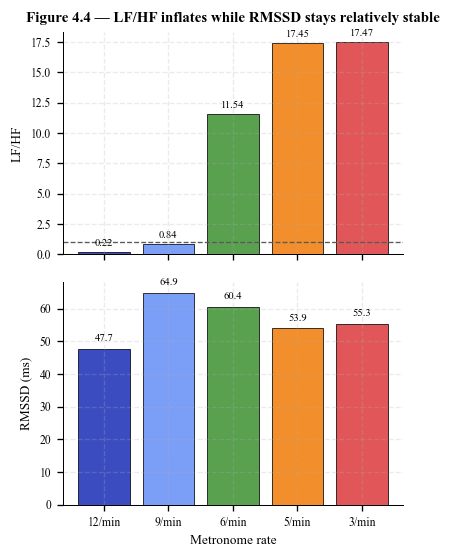

In [7]:
rate_labels = [f"{cfg.E4A_EXPECTED_BREATHING_HZ[k] * 60:.0f}/min" for k in E4A_KEYS]
x = np.arange(len(E4A_KEYS))
ratio_vals = [results[k].fd_hrv["lf_hf_ratio"] for k in E4A_KEYS]
rmssd_vals = [results[k].td_hrv["rmssd_ms"] for k in E4A_KEYS]
colors = [E4A_PSD_COLORS[k] for k in E4A_KEYS]

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(3.5, 4.7), sharex=True, gridspec_kw={"height_ratios": [1, 1]}
)

ax1.bar(x, ratio_vals, color=colors, edgecolor="black", linewidth=0.45)
ax1.axhline(1.0, color="0.35", linestyle="--", linewidth=0.8)
ax1.set_ylabel("LF/HF")
ax1.set_title("Figure 4.4 — LF/HF inflates while RMSSD stays relatively stable")
for xi, yi in zip(x, ratio_vals):
    ax1.text(xi, yi + 0.35, f"{yi:.2f}", ha="center", va="bottom", fontsize=6.4)

ax2.bar(x, rmssd_vals, color=colors, edgecolor="black", linewidth=0.45)
ax2.set_ylabel("RMSSD (ms)")
ax2.set_xlabel("Metronome rate")
for xi, yi in zip(x, rmssd_vals):
    ax2.text(xi, yi + 1.8, f"{yi:.1f}", ha="center", va="bottom", fontsize=6.4)

ax2.set_xticks(x, rate_labels)
ax1.grid(axis="y", linestyle="--", alpha=0.25)
ax2.grid(axis="y", linestyle="--", alpha=0.25)
fig.tight_layout()
save_paper_png(fig, "MAIN_17_nb05_exp4a_lfhf_vs_rmssd.png")
plt.show()

## 6. Figure 4.5 — Resonance amplitude reported honestly

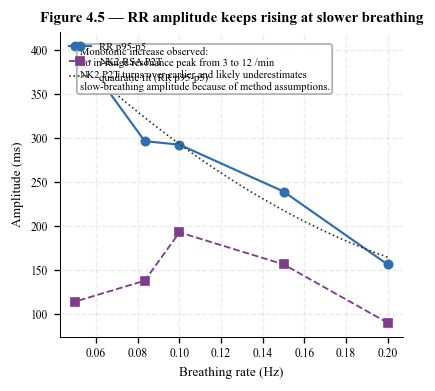

,Condition,Rate (Hz),RR p95-p5 (ms),NK2 RSA P2T (ms)
0,E4A_12pm,0.200,156.5,90.095
1,E4A_9pm,0.150,239.5,156.581
2,E4A_6pm,0.100,292.8,193.000
3,E4A_5pm,0.083,296.8,138.000
4,E4A_3pm,0.050,405.5,114.278


In [8]:
rates_hz = np.array([cfg.E4A_EXPECTED_BREATHING_HZ[k] for k in E4A_KEYS], dtype=float)
amps_ptp = np.array(
    [float(np.percentile(results[k].rr_ms_nk, 95) - np.percentile(results[k].rr_ms_nk, 5)) for k in E4A_KEYS],
    dtype=float,
)
amps_rsa = np.array([rsa_pub[k].get("RSA_P2T_Mean", np.nan) for k in E4A_KEYS], dtype=float)
quad_coef = np.polyfit(rates_hz, amps_ptp, 2)
fit_x = np.linspace(rates_hz.min(), rates_hz.max(), 300)
fit_y = np.polyval(quad_coef, fit_x)

vertex_hz = np.nan
peak_ci = None
if quad_coef[0] < 0:
    vertex_hz = -quad_coef[1] / (2 * quad_coef[0])
    if rates_hz.min() <= vertex_hz <= rates_hz.max():
        boot = []
        rng = np.random.default_rng(42)
        for _ in range(2000):
            idx = rng.integers(0, len(rates_hz), len(rates_hz))
            xb = rates_hz[idx]
            yb = amps_ptp[idx]
            if len(np.unique(xb)) < 3:
                continue
            coef_b = np.polyfit(xb, yb, 2)
            if coef_b[0] >= 0:
                continue
            vb = -coef_b[1] / (2 * coef_b[0])
            if rates_hz.min() <= vb <= rates_hz.max():
                boot.append(vb)
        if boot:
            peak_ci = np.percentile(np.asarray(boot), [2.5, 97.5])

fig, ax = plt.subplots(figsize=(3.5, 3.3))
ax.plot(rates_hz, amps_ptp, "o-", color="#2f6db3", linewidth=1.3, markersize=5.0, label="RR p95-p5")
ax.plot(rates_hz, amps_rsa, "s--", color="#7f3c8d", linewidth=1.1, markersize=4.5, label="NK2 RSA P2T")
ax.plot(fit_x, fit_y, color="0.2", linestyle=":", linewidth=1.0, label="quadratic fit (RR p95-p5)")

ax.set_xlabel("Breathing rate (Hz)")
ax.set_ylabel("Amplitude (ms)")
ax.set_title("Figure 4.5 — RR amplitude keeps rising at slower breathing")
ax.grid(True, linestyle="--", alpha=0.25)
ax.legend(loc="upper left", fontsize=6.4, frameon=False)

if np.isfinite(vertex_hz) and peak_ci is not None:
    conclusion = (
        f"Inverted-U fit peak: {vertex_hz:.3f} Hz\n"
        f"bootstrap 95% CI: [{peak_ci[0]:.3f}, {peak_ci[1]:.3f}] Hz"
    )
else:
    conclusion = (
        "Monotonic increase observed:\n"
        "no in-range resonance peak from 3 to 12 /min\n"
        "NK2 P2T turns over earlier and likely underestimates\n"
        "slow-breathing amplitude because of method assumptions."
    )
ax.text(
    0.052,
    ax.get_ylim()[1] * 0.96,
    conclusion,
    fontsize=6.4,
    va="top",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.65", alpha=0.92),
)

fig.tight_layout()
save_paper_png(fig, "MAIN_18_nb05_exp4a_resonance_amplitude.png")
plt.show()

amplitude_df = pd.DataFrame(
    {
        "Condition": E4A_KEYS,
        "Rate (Hz)": rates_hz,
        "RR p95-p5 (ms)": amps_ptp,
        "NK2 RSA P2T (ms)": amps_rsa,
    }
)
display(amplitude_df.round(3))

## 7. Table 4.1 — Expanded paced-breathing metric matrix

In [9]:
rows = []
for key in E4A_KEYS:
    r = results[key]
    exp_hz = cfg.E4A_EXPECTED_BREATHING_HZ[key]
    meas_hz = peak_pub[key]
    edr = edr_pub[key]
    rsa = rsa_pub[key]
    rows.append(
        {
            "Condition": key,
            "Expected rate (Hz)": exp_hz,
            "Expected rate (/min)": exp_hz * 60,
            "Measured RR peak (Hz)": meas_hz,
            "Peak deviation (Hz)": abs(meas_hz - exp_hz),
            "Peak within tolerance": cfg.check_freq_match(meas_hz, exp_hz),
            "EDR Welch peak (Hz)": edr["welch_peak_hz"],
            "EDR rate (/min)": edr["rate_bpm"],
            "Mean HR (bpm)": r.td_hrv["mean_hr_bpm"],
            "SDNN (ms)": r.td_hrv["sdnn_ms"],
            "RMSSD (ms)": r.td_hrv["rmssd_ms"],
            "Total Power (ms²)": r.fd_hrv["total_power_ms2"],
            "LF (ms²)": r.fd_hrv["lf_ms2"],
            "HF (ms²)": r.fd_hrv["hf_ms2"],
            "LF_nu (%)": r.fd_hrv["lf_nu"],
            "HF_nu (%)": r.fd_hrv["hf_nu"],
            "LF/HF": r.fd_hrv["lf_hf_ratio"],
            "RR p95-p5 (ms)": float(np.percentile(r.rr_ms_nk, 95) - np.percentile(r.rr_ms_nk, 5)),
            "NK2 P2T Mean (ms)": rsa.get("RSA_P2T_Mean", np.nan),
            "NK2 P2T SD (ms)": rsa.get("RSA_P2T_SD", np.nan),
            "Porges-Bohrer": rsa.get("RSA_PorgesBohrer", np.nan),
        }
    )

df_t41 = pd.DataFrame(rows)
df_t41.to_csv(TBL_DIR / "table_4_1_paced.csv", index=False)
display(df_t41.style.format(precision=3).set_caption("Table 4.1 — Paced-breathing metric matrix"))

,Condition,Expected rate (Hz),Expected rate (/min),Measured RR peak (Hz),Peak deviation (Hz),Peak within tolerance,EDR Welch peak (Hz),EDR rate (/min),Mean HR (bpm),SDNN (ms),RMSSD (ms),Total Power (ms²),LF (ms²),HF (ms²),LF_nu (%),HF_nu (%),LF/HF,RR p95-p5 (ms),NK2 P2T Mean (ms),NK2 P2T SD (ms),Porges-Bohrer
0,E4A_12pm,0.200,12.000,0.203,0.003,True,0.200,12.100,59.400,48.684,47.742,1754.316,279.147,1241.555,18.356,81.644,0.225,156.500,90.095,39.403,-5.237
1,E4A_9pm,0.150,9.000,0.148,0.002,True,0.150,9.004,57.015,77.978,64.857,2380.624,953.394,1129.024,45.783,54.217,0.844,239.500,156.581,35.286,-5.314
2,E4A_6pm,0.100,6.000,0.102,0.002,True,0.100,6.638,60.149,91.276,60.425,6086.693,5470.443,473.946,92.027,7.973,11.542,292.800,193.000,78.283,-5.839
3,E4A_5pm,0.083,5.000,0.086,0.003,True,0.167,9.151,59.886,95.930,53.931,8240.467,7634.220,437.480,94.580,5.420,17.450,296.800,138.000,122.657,-5.937
4,E4A_3pm,0.050,3.000,0.047,0.003,True,0.150,8.375,58.136,131.378,55.262,10493.096,8979.587,514.032,94.585,5.415,17.469,405.500,114.278,110.749,-5.760


*Table note.* Band powers follow Task Force 1996. Under slow breathing
(`≤ 9 /min`), the dominant spectral peak migrates outside the HF band, so
**HF power no longer indexes vagal tone cleanly**. RMSSD is therefore kept
as a frequency-boundary-independent vagal proxy.

## Methods

Experiment 4A used five paced-breathing conditions performed in a **fixed
descending order**: `12`, `9`, `6`, `5`, and `3 breaths/min`
(`0.200`, `0.150`, `0.100`, `0.0833`, and `0.050 Hz`). The subject followed
a visual metronome while seated and stationary. Each condition lasted
approximately 4 minutes, except the `3/min` condition, which was extended to
5 minutes to capture a sufficient number of respiratory cycles. The first
10 seconds of each file were discarded to avoid startup settling, leaving the
analysis windows defined in `src/config.py`. Because the order was not
randomized, any cumulative training, relaxation, or fatigue effect is
inseparable from the breathing-rate manipulation and must be treated as a
design limitation rather than ignored.

Signal processing followed the shared repository pipeline without changing
`src/pipeline.py`. Each recording was loaded with `P.load_ecg()`, filtered by
`P.filter_ecg()` (two-stage median baseline removal, 50 Hz notch, and
0.5–40 Hz Butterworth bandpass), and processed with the NeuroKit2 reference
detector `P.detect_qrs_nk()` plus Kubios-style peak correction. RR intervals
were then reconstructed with `P.compute_rr()`. Standard HRV summary metrics
came from the notebook's `results[k].td_hrv` and `results[k].fd_hrv`, which
preserve the repository's default Welch settings (`nperseg=256`) for the
canonical Task-Force band estimates reported in Table 4.1.

For publication figures, a second visualization-only PSD pass was computed
with `P.rr_psd(..., nperseg=512)`, giving a frequency resolution of
`0.0078 Hz`. This did not replace the standard HRV computation; it
only sharpened the displayed respiratory peak locations in Figures 4.2 and
4.3. Respiratory cross-checks were performed with ECG-derived respiration
(`P.derive_respiration_from_ecg`), and RSA amplitude was summarized using two
complementary metrics: a distributional RR amplitude index (`p95 - p5`) and
NeuroKit2's `RSA_P2T_Mean`. The dual-metric design was intentional because
P2T can underestimate very slow breathing when its underlying filtering and
cycle assumptions are stressed.

Peak-tracking statistics were based on `scipy.stats.linregress`. We reported
slope and intercept with 95% confidence intervals (`df = 3`), the residual
standard deviation in Hz, and explicit hypothesis tests for `H₀: slope = 1`
and `H₀: intercept = 0`. This is a small-sample analysis (`N = 5` conditions),
so the intervals are necessarily wide; the emphasis is therefore on the
combination of quantitative agreement, tiny peak deviations, and the visual
coherence of the spectra rather than on overclaiming precision.

## Results

**Peak frequency tracked the imposed breathing rate with near-identity
behaviour.** Using the higher-resolution visualization PSD
(`nperseg = 512`, `Δf = 0.0078 Hz`), the measured RR peak
frequencies were `0.2031`, `0.1484`, `0.1016`, `0.0859`, and `0.0469 Hz` for
the `12`, `9`, `6`, `5`, and `3 /min` conditions, respectively. Linear
regression gave a slope of `1.022` (95% CI
`[0.947, 1.097]`) and intercept
`-0.0020` (95% CI
`[-0.0116, 0.0076]`), with `R² = 0.998` and
residual SD `0.0028 Hz`. The slope was not distinguishable from `1`
(`p = 0.422`), and the intercept was not
distinguishable from `0` (`p = 0.549`), which is
the pattern expected if spectral peak detection is tracking the imposed
breathing frequency rather than drifting systematically. Absolute peak
deviations stayed between `0.0016` and `0.0031 Hz`,
well within the notebook's tolerance rule.

**Band migration, not abrupt vagal withdrawal, explains the dramatic LF/HF
inflation at slow breathing.** LF/HF rose from `0.22` at `12/min` to
`11.54` at `6/min`, then remained very high at `17.45` and
`17.47` for `5/min` and `3/min`. By contrast, RMSSD stayed within a
much narrower range (`47.7–64.9 ms`) rather than
collapsing, and mean heart rate stayed close to `58–60 bpm`. The frequency
interpretation is straightforward: once breathing slowed below the classical
`0.15 Hz` HF boundary, the respiratory oscillation moved leftward into LF, so
LF/HF no longer reflected a shift toward sympathetic dominance. Figure 4.4 is
therefore intentionally framed as a demonstration of **band-label failure**
under slow breathing, not as evidence of autonomic imbalance.

**Amplitude increased progressively as breathing slowed.** SDNN climbed
monotonically from `48.7` to `131.4 ms`, and RR amplitude
(`p95 - p5`) likewise increased from `156.5` to
`405.5 ms`. Total power increased from `1754`
to `10493 ms²`, a roughly `6.0×` rise
across the tested range. This means the data did **not** show the expected
classical inverted-U resonance peak centered at `6/min`; instead, the largest
RR oscillations were observed at the slowest tested rate (`3/min`). The
secondary RSA metric behaved differently: `RSA_P2T_Mean` increased from
`90.1` to a local maximum of `193.0 ms` at `6/min`
and then decreased. We treat that turnover cautiously because P2T is more
sensitive to method assumptions and may underestimate very slow breathing.

**Taken together, the four upgraded outputs are internally consistent.**
Figure 4.2 shows the same leftward peak migration quantified in Figure 4.3;
Figure 4.4 explains why LF/HF becomes misleading once the oscillation crosses
the HF/LF boundary; Figure 4.5 shows that the amplitude finding is monotonic
in the raw RR data even though an algorithm-specific RSA metric suggests an
apparent peak near `6/min`; and Table 4.1 confirms that the EDR cross-check,
total power, normalized units, and peak deviations all tell the same story.

## Discussion

Experiment 4A complements the breath-hold results from Experiment 2 by
showing the other side of cardiorespiratory coupling: instead of disrupting
respiration, we controlled it. The strongest conclusion is not merely that
paced breathing modulates HRV, but that **where the oscillation lands in the
spectrum matters as much as how large it is**. Once the respiratory peak
crosses below `0.15 Hz`, Task-Force LF/HF becomes a fragile label rather than
a faithful autonomic summary. In this notebook, RMSSD remained relatively
stable while LF/HF exploded, which is exactly the signature expected from band
migration rather than true sympathovagal reversal.

The second important implication is methodological. Classical resonance
biofeedback is often framed as if `~6/min` should produce a clear inverted-U
amplitude maximum. These data do not support that simplified picture. Within
the tested range, RR amplitude continued to grow down to `3/min`, while the
NeuroKit2 P2T metric turned over earlier. A cautious reading is that the
underlying physiology may continue to favor larger oscillations at slower
rates, but some derived RSA metrics become less trustworthy when the breathing
cycle gets very long. That is why this notebook reports the monotonic RR
finding directly instead of forcing an artificial resonance peak narrative.

The main limitation is the **fixed descending order** (`12 → 9 → 6 → 5 → 3
/min`). Because the protocol was not randomized, later conditions may reflect
greater metronome familiarity, deeper relaxation, accumulated fatigue, or
slow drift in posture and vigilance. The monotonic SDNN increase could
therefore be partly physiological, partly procedural, or both. Future work
should randomize order, repeat each rate in separate blocks, and ideally add a
direct respiratory belt to validate EDR under very slow breathing. Even with
that caveat, the current dataset still makes one robust contribution: it
demonstrates that frequency-boundary-based HRV interpretation can break down
badly during slow paced breathing, and that publication-quality reporting must
say so explicitly.